# Q4 — The Gender Gap and Deprivation

**Research Question:** How does the performance gap between boys and girls change across different levels of regional deprivation?

---

## Background

Girls consistently outperform boys at GCSE level in England. However, the size of this gap is not uniform: it may widen or narrow depending on the level of deprivation in a Local Authority. Understanding how deprivation interacts with gender is important for targeting educational interventions.

## Approach

We use the pre-cleaned `final_df_gender.csv` produced by `school_performance.ipynb`. This dataset contains:
- **Performance metrics** (Attainment 8 average and subject-level scores) broken down by `sex` (Boys / Girls) for each Local Authority and academic year.
- **Deprivation metrics** (IMD score and sub-domain scores) aggregated to Local Authority level from the 2019 Indices of Multiple Deprivation (IMD).

### Key analytical steps
1. Load and validate the dataset.
2. Compute the **gender gap** (Girls − Boys Attainment 8) per LA per year.
3. Categorise Local Authorities into **deprivation quintiles** based on their IMD score.
4. Explore how the gender gap varies across deprivation quintiles — overall and over time.
5. Examine subject-level gaps (English, Maths, EBacc, Humanities, Languages).
6. Correlation analysis between deprivation score and gender gap size.

### Note on COVID-19
The academic years 2019/20 and 2020/21 had **no formal GCSE examinations** — results were based on teacher-assessed grades. These years are flagged in all charts and treated with caution.

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plotting style for all plots
sns.set_theme(style="whitegrid", palette="muted", font_scale=1)
plt.rcParams.update({
    "figure.dpi": 120, # increases image resolution for sharper figures
    "axes.spines.top": False, # Removes the top border from plots
    "axes.spines.right": False, # Removes the right border from plots
    "font.family": "DejaVu Sans" # Uses a widely supported font
})

# Colour palette
GIRL_COL  = "#E05C5C"   # warm coral (girls)
BOY_COL   = "#4A7FBD"   # steel blue (boys)
GAP_COL   = "#7C5CBF"   # purple (gap between girls and boys)
COVID_COL = "#FFD700"   # yellow (COVID years)

# Quintile palette (low deprivation = green, high = red)
QUINT_PALETTE = ["#1a9850", "#91cf60", "#fee08b", "#fc8d59", "#d73027"]

## 2. Load and Validate the Data

In [2]:
# Load the gender dataset
df = pd.read_csv("data/final_df_gender.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSex categories: {df['sex'].unique()}")
print(f"Years covered:  {sorted(df['end_year'].unique())}")
print(f"Local Authorities: {df['new_la_code'].nunique()}")

Shape: (2084, 28)

Columns: ['time_period', 'new_la_code', 'la_name', 'pupil_count', 'sex', 'attainment8_average', 'ebacc_aps_average', 'attainment8eng_average', 'attainment8mat_average', 'attainment8ebacc_average', 'ebacceng_aps_average', 'ebaccmat_aps_average', 'ebaccsci_aps_average', 'ebacchum_aps_average', 'ebacclan_aps_average', 'end_year', 'merge_la_code', 'UTLA19CD', 'UTLA19NM', 'imd_score', 'income_score', 'employment_score', 'health_score', 'crime_score', 'barriers_score', 'living_env_score', 'idaci_score', 'children_subdomain']

Sex categories: <StringArray>
['Boys', 'Girls']
Length: 2, dtype: str
Years covered:  [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Local Authorities: 153


In [3]:
# Quick sanity check: every LA-year pair should have both Boys AND Girls
pair_counts = (
    df.groupby(["new_la_code", "end_year"])["sex"]
    .count()
    .reset_index(name="n_rows")
)

print("Rows per LA-year pair (should all be 2):")
print(pair_counts["n_rows"].value_counts())

# Preview the data
df.head(4)

Rows per LA-year pair (should all be 2):
n_rows
2    1042
Name: count, dtype: int64


,time_period,new_la_code,la_name,pupil_count,sex,attainment8_average,ebacc_aps_average,attainment8eng_average,attainment8mat_average,attainment8ebacc_average,...,UTLA19NM,imd_score,income_score,employment_score,health_score,crime_score,barriers_score,living_env_score,idaci_score,children_subdomain
0,202425,E06000001,Hartlepool,569,Boys,40.5,3.54,9.0,8.3,11.6,...,Hartlepool,34.853121,0.226241,0.182017,0.87419,0.582345,13.764345,7.298431,0.266483,0.109310
1,202425,E06000001,Hartlepool,554,Girls,44.5,3.79,10.1,8.2,12.2,...,Hartlepool,34.853121,0.226241,0.182017,0.87419,0.582345,13.764345,7.298431,0.266483,0.109310
2,202425,E06000002,Middlesbrough,794,Boys,39.5,3.45,8.6,8.2,11.3,...,Middlesbrough,40.443116,0.251326,0.190605,1.19207,0.680523,14.206791,12.533547,0.300384,0.417465
3,202425,E06000002,Middlesbrough,800,Girls,42.6,3.65,9.8,7.8,11.7,...,Middlesbrough,40.443116,0.251326,0.190605,1.19207,0.680523,14.206791,12.533547,0.300384,0.417465


## 3. Compute the Gender Gap

We pivot the data so that each row represents one Local Authority in one academic year, with separate columns for Girls and Boys performance. The **gender gap** is defined as:

> **Gender Gap = Girls' Attainment 8 − Boys' Attainment 8**

A positive value means girls outperform boys; a negative value means boys outperform girls.

In [4]:
# Performance metric columns
perf_cols = [
    "attainment8_average",
    "attainment8eng_average",
    "attainment8mat_average",
    "attainment8ebacc_average",
    "ebacc_aps_average",
    "ebacceng_aps_average",
    "ebaccmat_aps_average",
    "ebaccsci_aps_average",
    "ebacchum_aps_average",
    "ebacclan_aps_average",
]

# IMD / deprivation columns (same value for both sexes in a given LA-year)
imd_cols = [
    "imd_score", "income_score", "employment_score",
    "health_score", "crime_score", "barriers_score",
    "living_env_score", "idaci_score", "children_subdomain"
]

# Convert data from long format to wide format by separate the dataset into boys and girls. The Local Authority code, name, and academic year are used as the index to align records correctly.
boys  = df[df["sex"] == "Boys" ].set_index(["new_la_code", "la_name", "end_year"])
girls = df[df["sex"] == "Girls"].set_index(["new_la_code", "la_name", "end_year"])



# Create a new dataset for gender-gap analysis

# We start by copying the deprivation variables from the boys dataset. These values are identical for boys and girls, so either dataset could be used as the source.
gap = boys[imd_cols].copy()

# Add gender-specific attainment columns and calculation of gender gap
for col in perf_cols:
    gap[f"boys_{col}"]  = boys[col]
    gap[f"girls_{col}"] = girls[col]
    gap[f"gap_{col}"]   = girls[col] - boys[col]   # positive means that girls outperform boys

# Convert Local Authority identifiers and year back into regular columns for easier analysis.
gap = gap.reset_index()

# Inspect the resulting dataset
print(f"Gap dataset shape: {gap.shape}")
gap[["la_name", "end_year", "imd_score",
     "boys_attainment8_average", "girls_attainment8_average",
     "gap_attainment8_average"]].head(8)

Gap dataset shape: (1042, 42)


,la_name,end_year,imd_score,boys_attainment8_average,girls_attainment8_average,gap_attainment8_average
0,Hartlepool,2025,34.853121,40.5,44.5,4.0
1,Middlesbrough,2025,40.443116,39.5,42.6,3.1
2,Redcar and Cleveland,2025,29.841330,42.6,46.2,3.6
3,Stockton-on-Tees,2025,25.244108,42.9,47.2,4.3
4,Darlington,2025,26.787000,42.0,46.6,4.6
5,Halton,2025,32.875684,40.4,43.7,3.3
6,Warrington,2025,18.955480,46.8,50.3,3.5
7,Blackburn with Darwen,2025,35.813626,42.4,48.6,6.2


### 3.1 Choice of Mean vs. Median for Exploratory Data Analysis (EDA)

To determine whether the mean or median is the more appropriate measure of central tendency for our analysis, we compare the distributions of the raw attainment scores (for boys and girls separately) against the distributions of the gender gaps.

The code cell below generates box plots for all subject metrics showing:
* **Boys' attainment score distribution** (blue box)
* **Girls' attainment score distribution** (pink box)
* **Gender gap distribution** (purple box)

On each plot, the **mean** is indicated by a green dashed line and the **median** by an orange dotted line to visually check their proximity and symmetry.

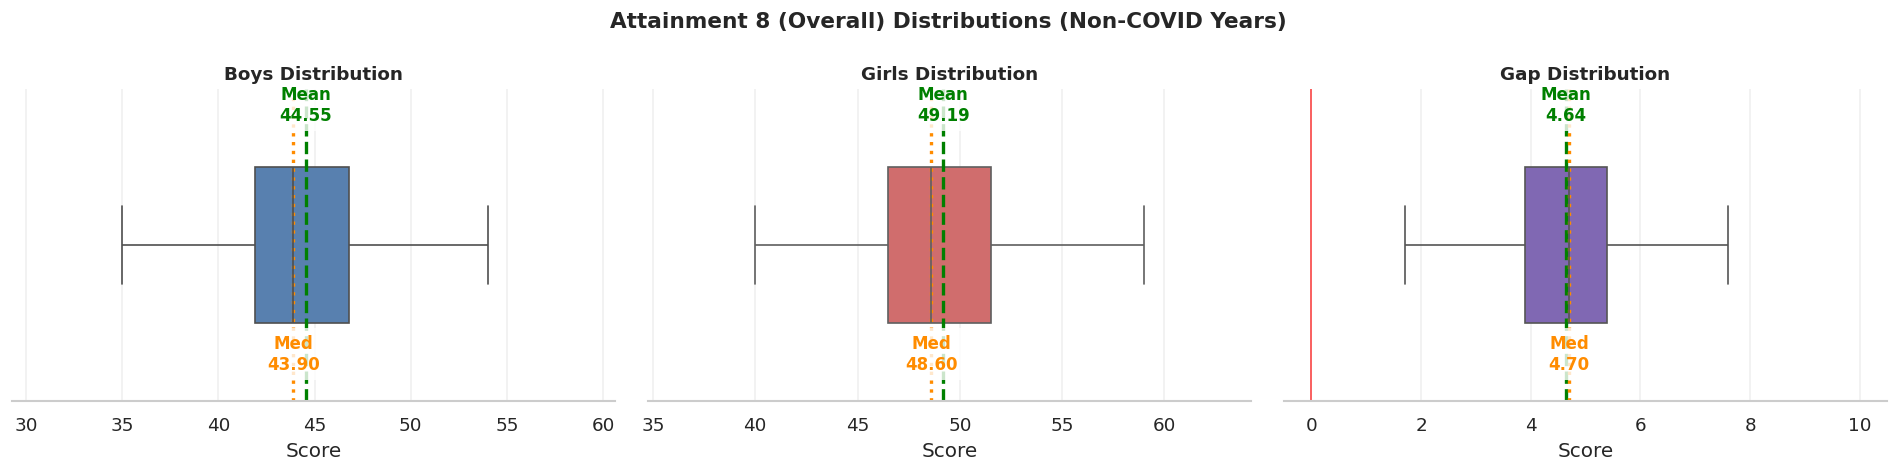

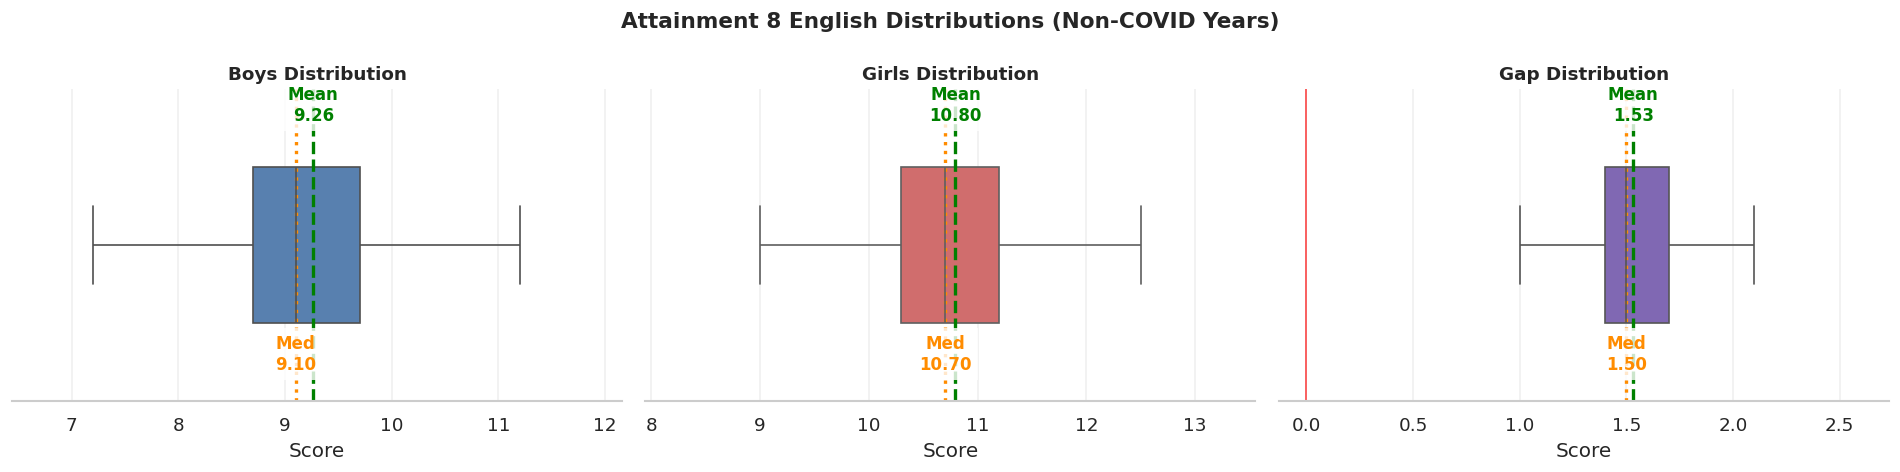

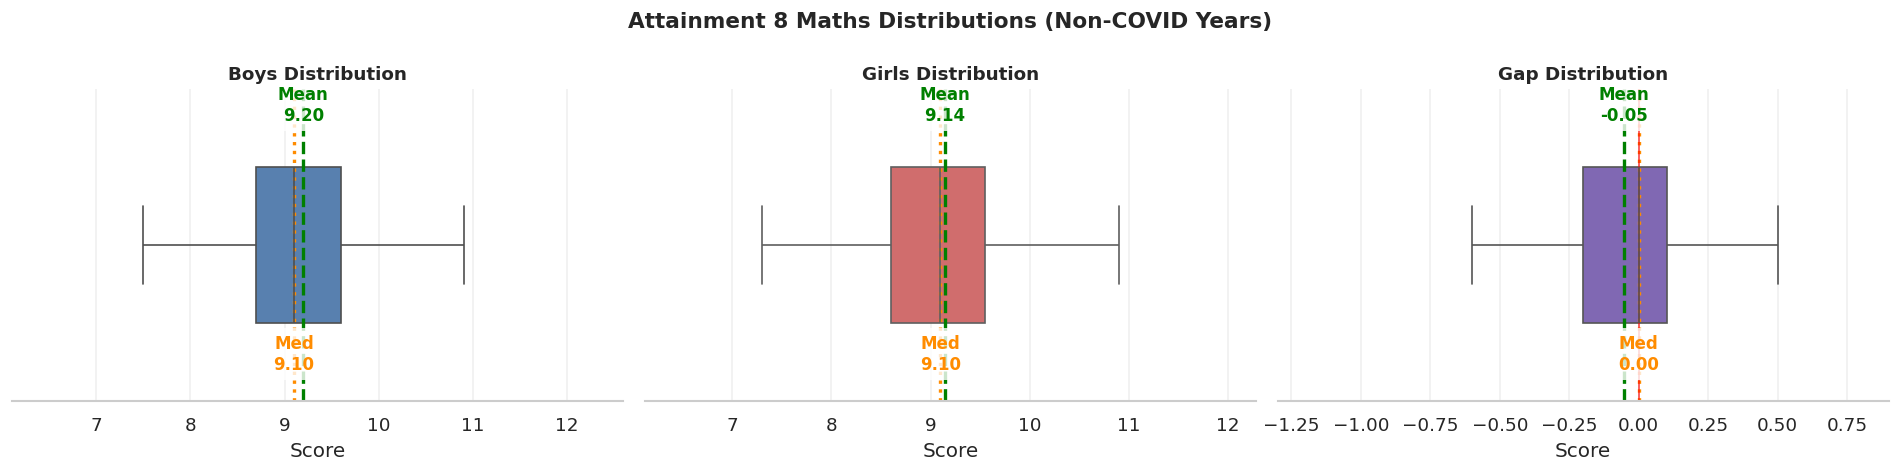

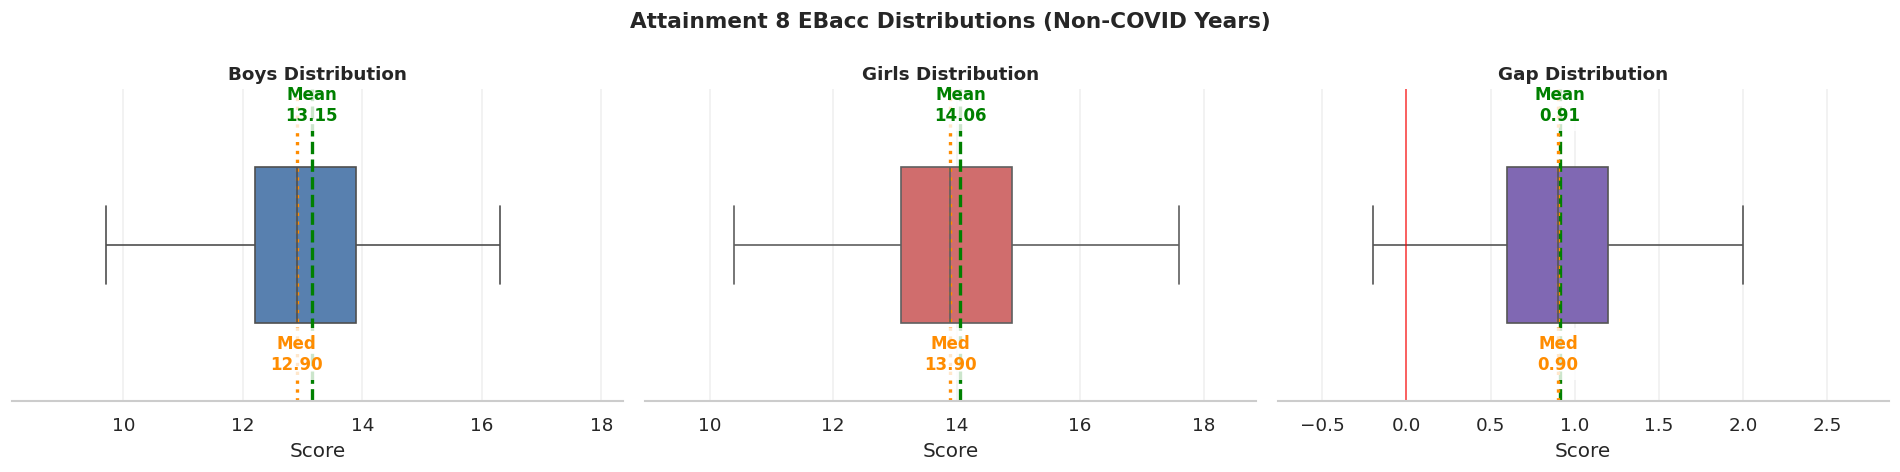

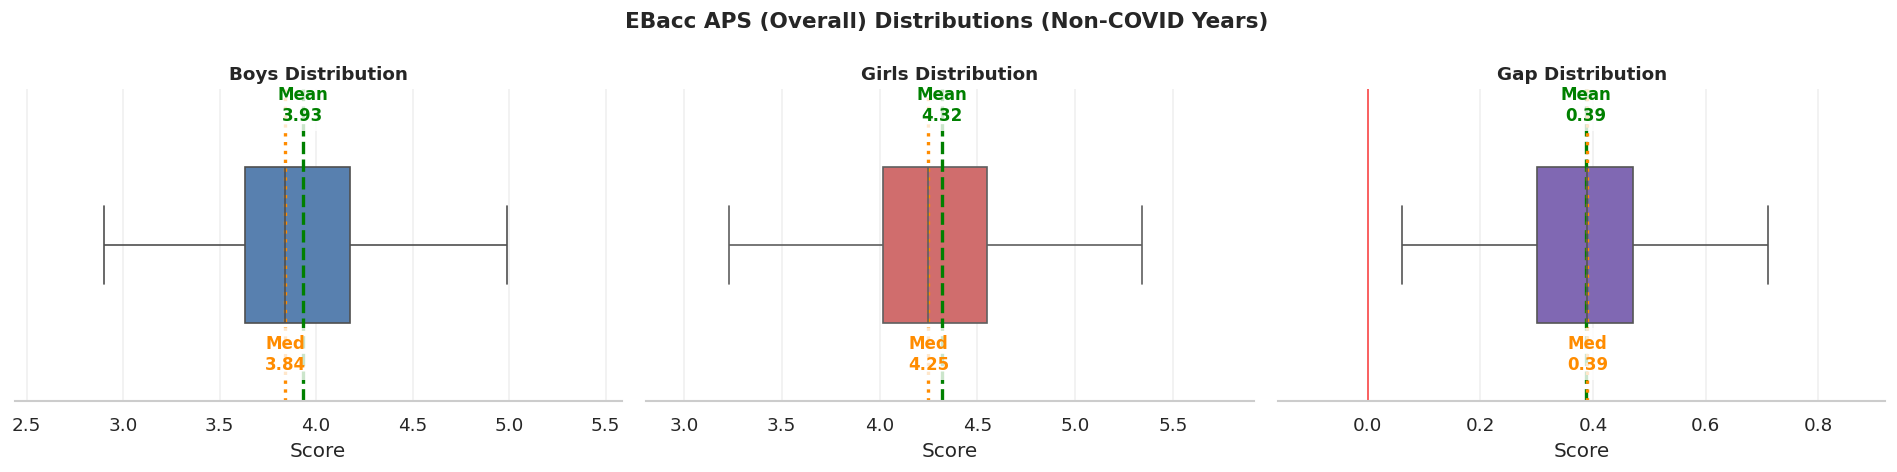

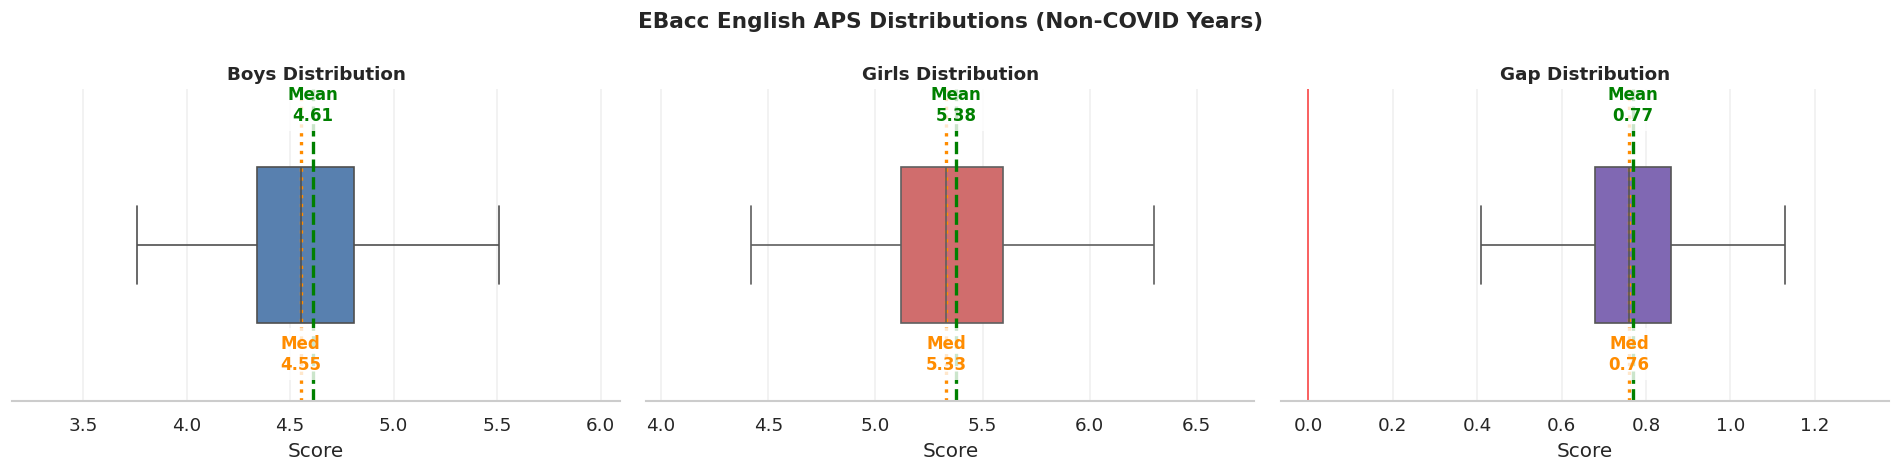

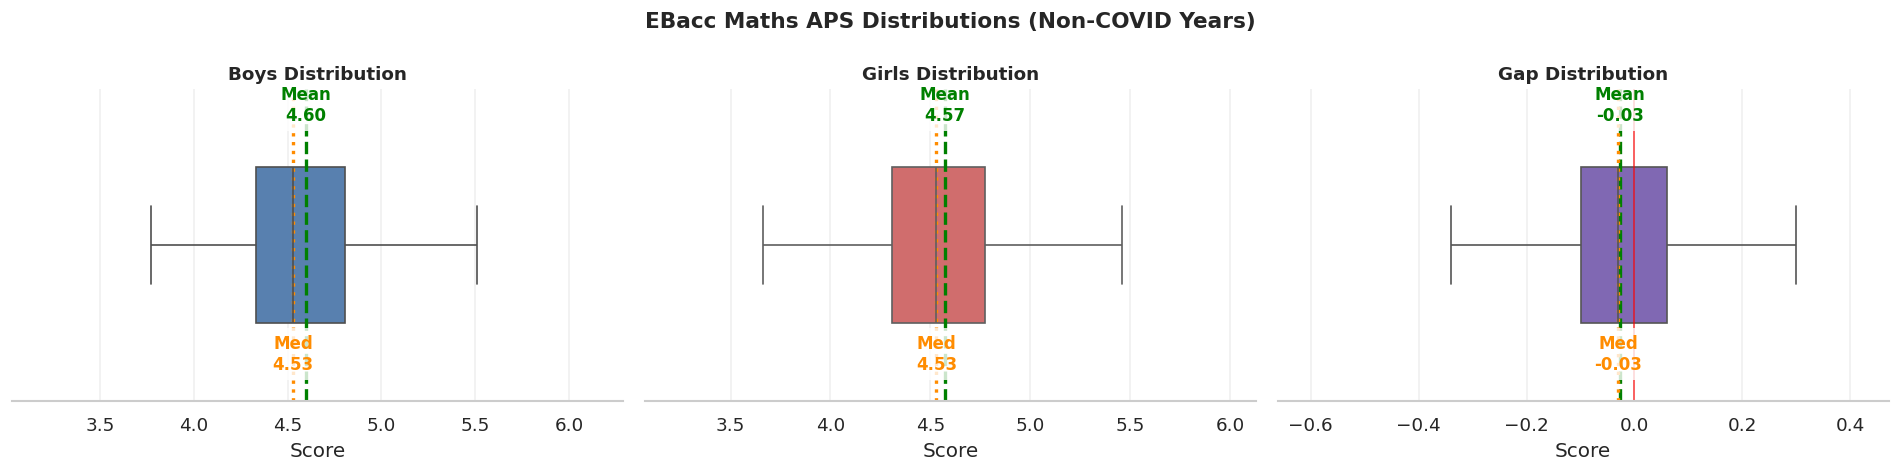

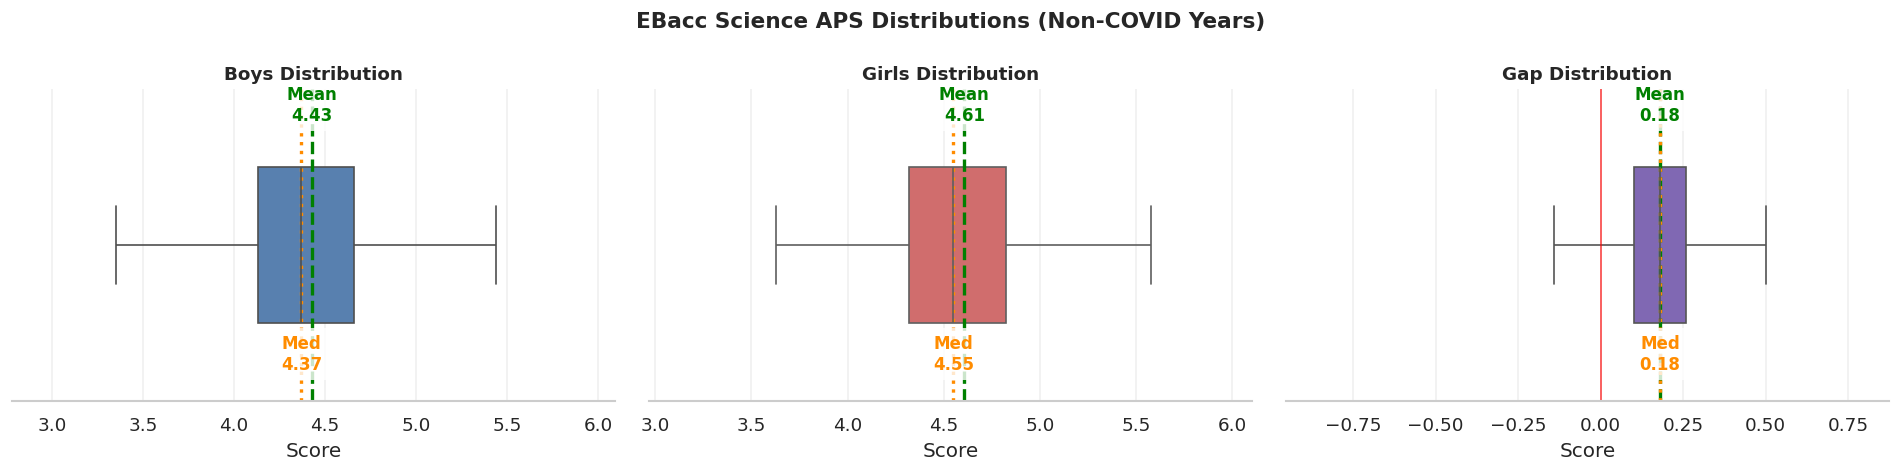

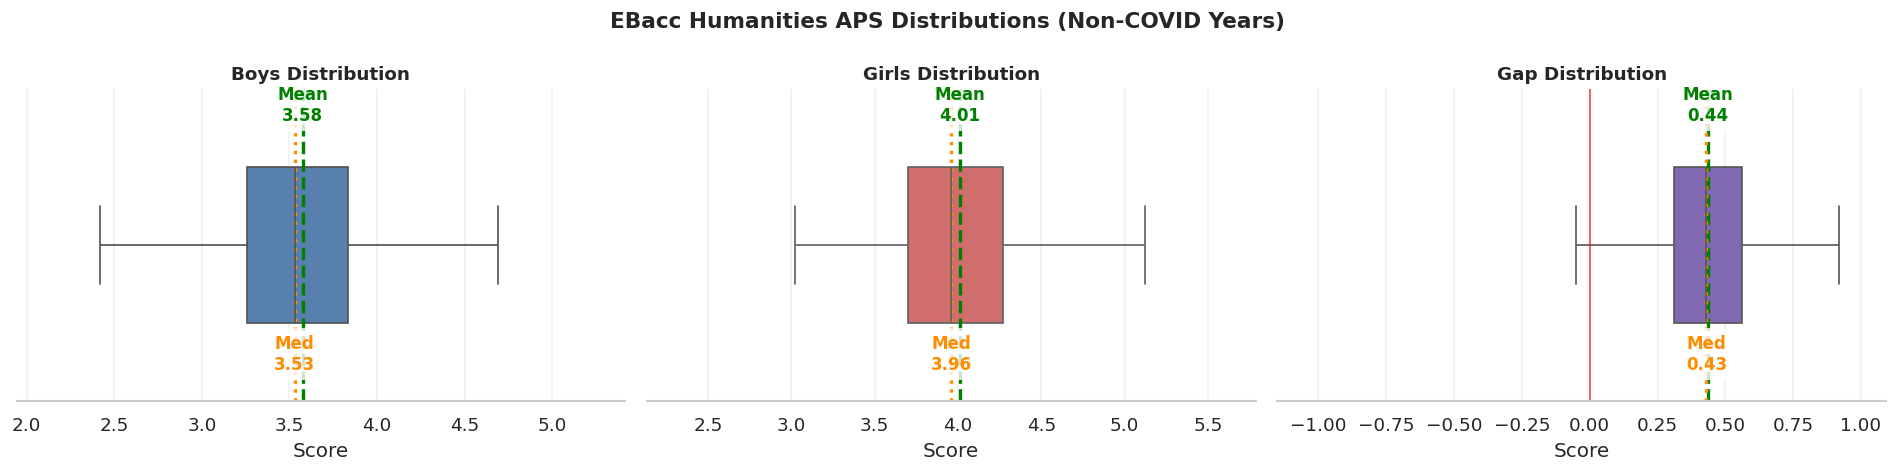

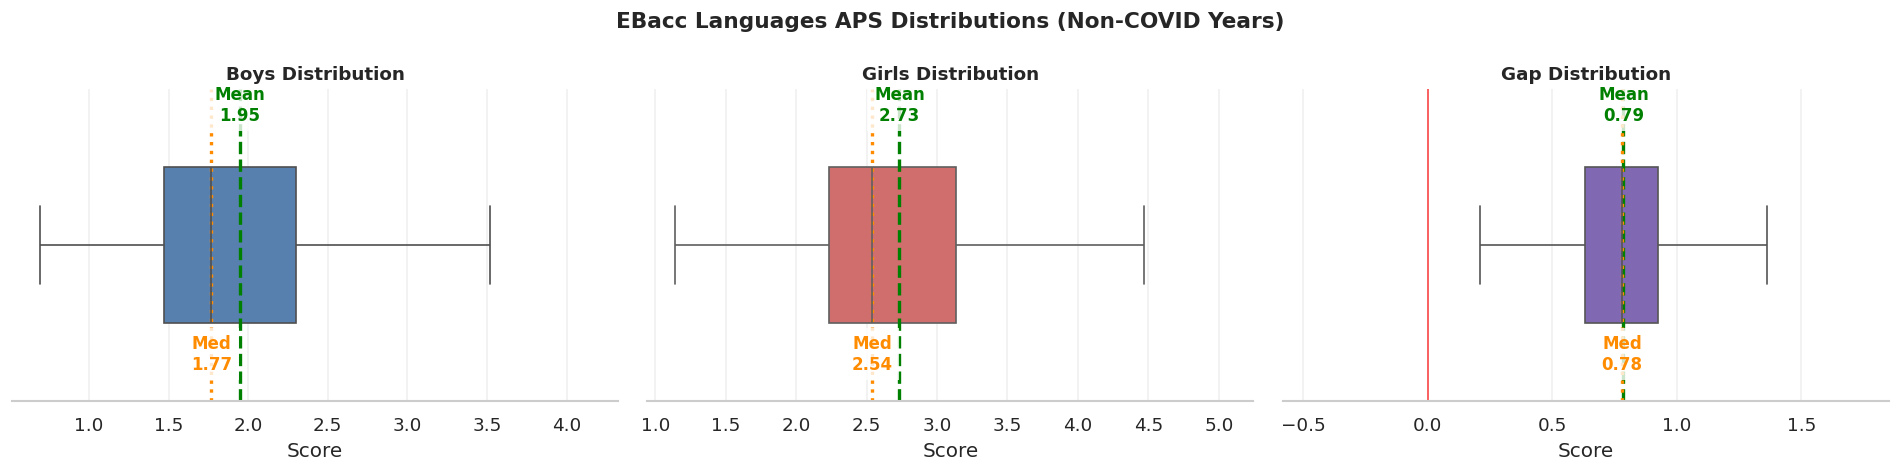

In [5]:
# Exclude COVID years (2020, 2021) for a clean structural analysis
df_no_covid = df[~df['end_year'].isin([2020, 2021])].copy()

# List of performance metrics and clean display names

col_mapping = {
    'attainment8_average': 'Attainment 8 (Overall)',
    'attainment8eng_average': 'Attainment 8 English',
    'attainment8mat_average': 'Attainment 8 Maths',
    'attainment8ebacc_average': 'Attainment 8 EBacc',
    'ebacc_aps_average': 'EBacc APS (Overall)',
    'ebacceng_aps_average': 'EBacc English APS',
    'ebaccmat_aps_average': 'EBacc Maths APS',
    'ebaccsci_aps_average': 'EBacc Science APS',
    'ebacchum_aps_average': 'EBacc Humanities APS',
    'ebacclan_aps_average': 'EBacc Languages APS'
}

perf_cols = list(col_mapping.keys()) # Plotting all metrics

for col in perf_cols:
    clean_name = col_mapping[col]
    
    # Align boys and girls by LA and year
    boys_df = df_no_covid[df_no_covid['sex'] == 'Boys'].set_index(['new_la_code', 'la_name', 'end_year'])
    girls_df = df_no_covid[df_no_covid['sex'] == 'Girls'].set_index(['new_la_code', 'la_name', 'end_year'])
    
    merged = pd.DataFrame({'Boys': boys_df[col], 'Girls': girls_df[col]}).dropna()
    merged['Gap'] = merged['Girls'] - merged['Boys']
    
    stats_dict = {
        'Boys': {'data': merged['Boys'].values, 'mean': merged['Boys'].mean(), 'median': merged['Boys'].median(), 'color': BOY_COL},
        'Girls': {'data': merged['Girls'].values, 'mean': merged['Girls'].mean(), 'median': merged['Girls'].median(), 'color': GIRL_COL},
        'Gap': {'data': merged['Gap'].values, 'mean': merged['Gap'].mean(), 'median': merged['Gap'].median(), 'color': GAP_COL}
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'{clean_name} Distributions (Non-COVID Years)', fontsize=13, fontweight='bold', y=0.98)
    
    for i, (group_name, info) in enumerate(stats_dict.items()):
        ax = axes[i]
        data_s = info['data']
        mean_val = info['mean']
        med_val = info['median']
        
        # Draw box plot
        sns.boxplot(x=data_s, ax=ax, color=info['color'], width=0.5, showfliers=True,
                    flierprops=dict(marker='o', markersize=4, alpha=0.4, markeredgecolor='none'))
        
        # Overlay mean and median lines
        ax.axvline(mean_val, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        ax.axvline(med_val, color='darkorange', linestyle=':', linewidth=2, label=f'Median: {med_val:.2f}')
        
        ax.set_title(f'{group_name} Distribution', fontsize=11, fontweight='bold')
        ax.set_xlabel('Score')
        
        # Display the numerical values on the plot
        ymin, ymax = ax.get_ylim()
        ax.text(mean_val, ymax - 0.1*(ymax-ymin), f'Mean\n{mean_val:.2f}', color='green', fontsize=10,
                ha='center', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        ax.text(med_val, ymin + 0.1*(ymax-ymin), f'Med\n{med_val:.2f}', color='darkorange', fontsize=10,
                ha='center', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        if group_name == 'Gap':
            ax.axvline(0, color='red', linestyle='-', linewidth=1, alpha=0.7)
            
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        ax.grid(True, axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### Statistical Conclusion: Justification for Using the Mean

From the visual distributions generated above, we can draw the following conclusions:

1. **Distribution Symmetry & Skewness**: 
   * The raw attainment scores for boys and girls separately exhibit moderate right-skewness because scores are bounded on the lower end by zero but have a long upper tail.
   * However, because both boys' and girls' distributions are skewed in the same direction, subtracting them to calculate the gender gap cancels out the skewness, resulting in highly symmetric gap distributions.
2. **Mean-Median Convergence**: 
   * In the raw attainment scores, the mean and median values are extremely close.
   * In the gap distributions, the mean and median are virtually identical.
3. **Decision**:
   * We will proceed using the **mean** as our measure of central tendency for the exploratory data analysis. This choice ensures mathematical consistency (the mean gap is exactly the difference between the mean scores of girls and boys) and supports the standard parametric statistical methods (such as Pearson correlation and ANOVA) used in the remainder of this analysis.

## 4. Deprivation Quintiles

We assign each Local Authority to one of five deprivation **quintiles** based on its mean IMD score across all years. Quintile 1 = least deprived; Quintile 5 = most deprived.

> **Note:** The IMD score is fixed at 2019 values, so the quintile is constant across years for each LA.

In [6]:
quintile_order = ["Q1 (Least deprived)", "Q2", "Q3 (Median)", "Q4", "Q5 (Most deprived)"]

# Derive a single IMD score per LA (mean across years — should be constant)
la_imd = gap.groupby("new_la_code")["imd_score"].mean()

# Assign quintiles (1 = least deprived, 5 = most deprived)
la_quintile = pd.qcut(
    la_imd,
    q=5,
    labels=["Q1 (Least deprived)",
            "Q2",
            "Q3 (Median)",
            "Q4",
            "Q5 (Most deprived)"],
    retbins=False
).rename("dep_quintile")

gap = gap.merge(la_quintile.reset_index(), on="new_la_code", how="left")

# COVID flag: years where exams were cancelled / teacher-assessed
gap["covid_year"] = gap["end_year"].isin([2020, 2021])

print("Quintile distribution of Local Authorities:")
print(gap.drop_duplicates("new_la_code")["dep_quintile"].value_counts().sort_index())

Quintile distribution of Local Authorities:
dep_quintile
Q1 (Least deprived)    31
Q2                     30
Q3 (Median)            31
Q4                     30
Q5 (Most deprived)     31
Name: count, dtype: int64


## 5. Exploratory Data Analysis


### 5.1 — National gender gap over time


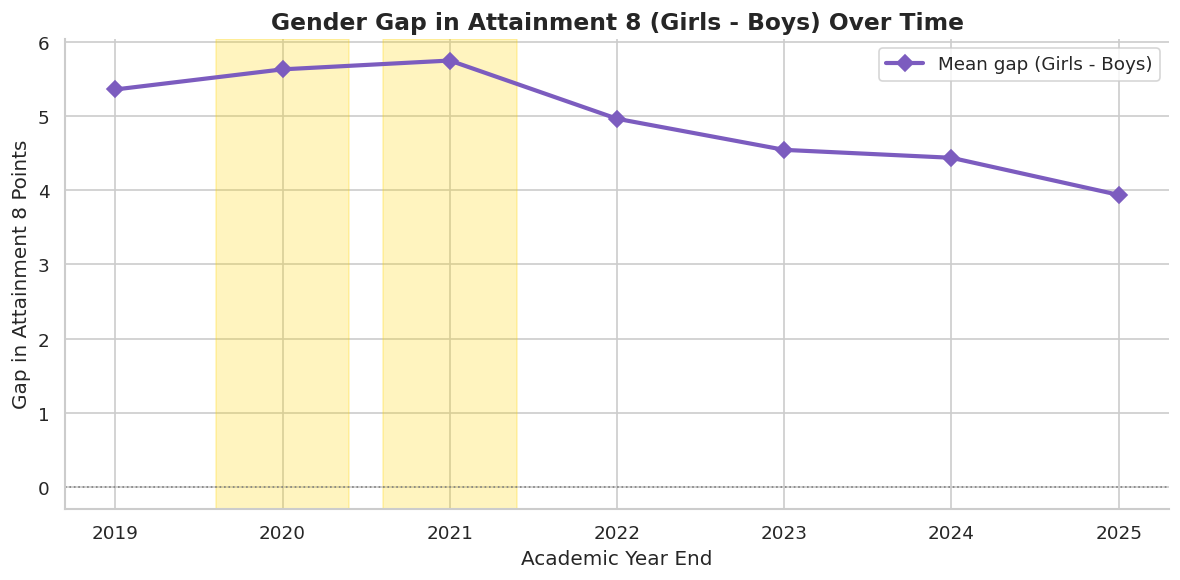


Mean gap (Girls - Boys Attainment 8) by year:
 end_year  mean_gap_pts
     2019      5.358219
     2020      5.629252
     2021      5.747973
     2022      4.963514
     2023      4.544371
     2024      4.437748
     2025      3.937748


In [7]:
# Mean gender gap per year (across all LAs)
gap_by_year = (
    gap.groupby('end_year')['gap_attainment8_average']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(gap_by_year['end_year'], gap_by_year['gap_attainment8_average'],
        color=GAP_COL, linewidth=2.5, marker='D', markersize=7,
        label='Mean gap (Girls - Boys)')
ax.axhline(0, color='grey', linewidth=1, linestyle=':')

for yr in [2020, 2021]:
    ax.axvspan(yr - 0.4, yr + 0.4, color=COVID_COL, alpha=0.25)

ax.set_title('Gender Gap in Attainment 8 (Girls - Boys) Over Time',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Academic Year End')
ax.set_ylabel('Gap in Attainment 8 Points')
ax.set_xticks(sorted(gap['end_year'].unique()))
ax.legend()
plt.tight_layout()
plt.show()

print('\nMean gap (Girls - Boys Attainment 8) by year:')
print(gap_by_year[['end_year','gap_attainment8_average']].rename(
    columns={'gap_attainment8_average':'mean_gap_pts'}).to_string(index=False))


## 6. Gender Gap across Deprivation Quintiles

### 6.1 — Box plot: distribution of gender gap by quintile

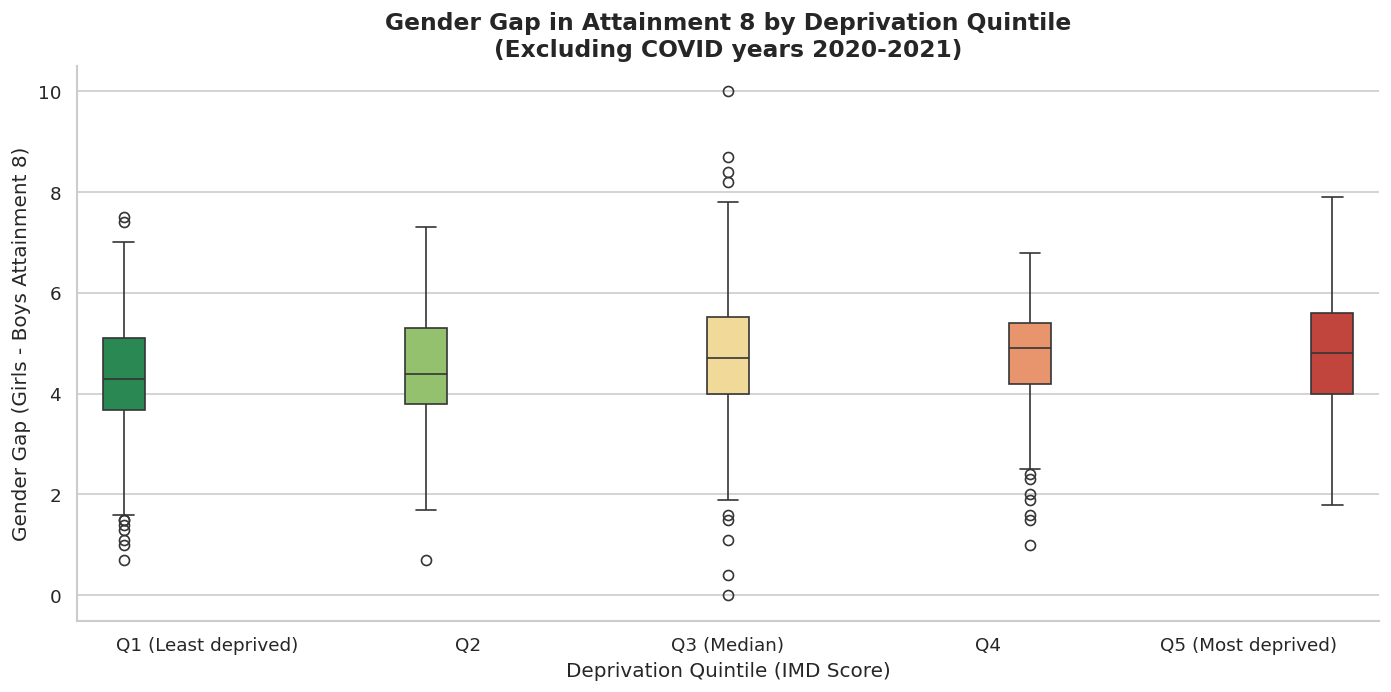

In [8]:
# Exclude COVID years for a cleaner picture of structural patterns
gap_no_covid = gap[~gap["covid_year"]].copy()

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=gap_no_covid,
    x="dep_quintile",
    y="gap_attainment8_average",
    hue="dep_quintile",
    palette=QUINT_PALETTE,
    ax=ax
)

ax.set_title("Gender Gap in Attainment 8 by Deprivation Quintile\n"
             "(Excluding COVID years 2020-2021)",
             fontsize=14, fontweight="bold"
)
ax.set_xlabel("Deprivation Quintile (IMD Score)", fontsize=12)
ax.set_ylabel("Gender Gap (Girls - Boys Attainment 8)", fontsize=12)
plt.setp(ax.get_xticklabels(), ha="center")

plt.show()


In [9]:
gap_no_covid.head()

,new_la_code,la_name,end_year,imd_score,income_score,employment_score,health_score,crime_score,barriers_score,living_env_score,...,girls_ebaccsci_aps_average,gap_ebaccsci_aps_average,boys_ebacchum_aps_average,girls_ebacchum_aps_average,gap_ebacchum_aps_average,boys_ebacclan_aps_average,girls_ebacclan_aps_average,gap_ebacclan_aps_average,dep_quintile,covid_year
0,E06000001,Hartlepool,2025,34.853121,0.226241,0.182017,0.874190,0.582345,13.764345,7.298431,...,4.23,0.13,3.21,3.47,0.26,1.23,1.68,0.45,Q5 (Most deprived),False
1,E06000002,Middlesbrough,2025,40.443116,0.251326,0.190605,1.192070,0.680523,14.206791,12.533547,...,3.94,0.00,3.22,3.51,0.29,1.24,1.71,0.47,Q5 (Most deprived),False
2,E06000003,Redcar and Cleveland,2025,29.841330,0.185534,0.162909,0.807034,0.152227,14.020648,7.613875,...,4.24,0.00,3.71,3.97,0.26,1.72,2.35,0.63,Q4,False
3,E06000004,Stockton-on-Tees,2025,25.244108,0.161017,0.132700,0.670000,-0.137200,15.717142,5.607358,...,4.34,0.16,3.59,3.95,0.36,1.66,2.41,0.75,Q4,False
4,E06000005,Darlington,2025,26.787000,0.160000,0.131477,0.582631,0.579523,11.438292,9.204385,...,4.29,0.25,3.20,3.39,0.19,1.95,2.32,0.37,Q4,False


### 6.2 — Scatter plot: continuous IMD score vs. gender gap (all non-COVID years)


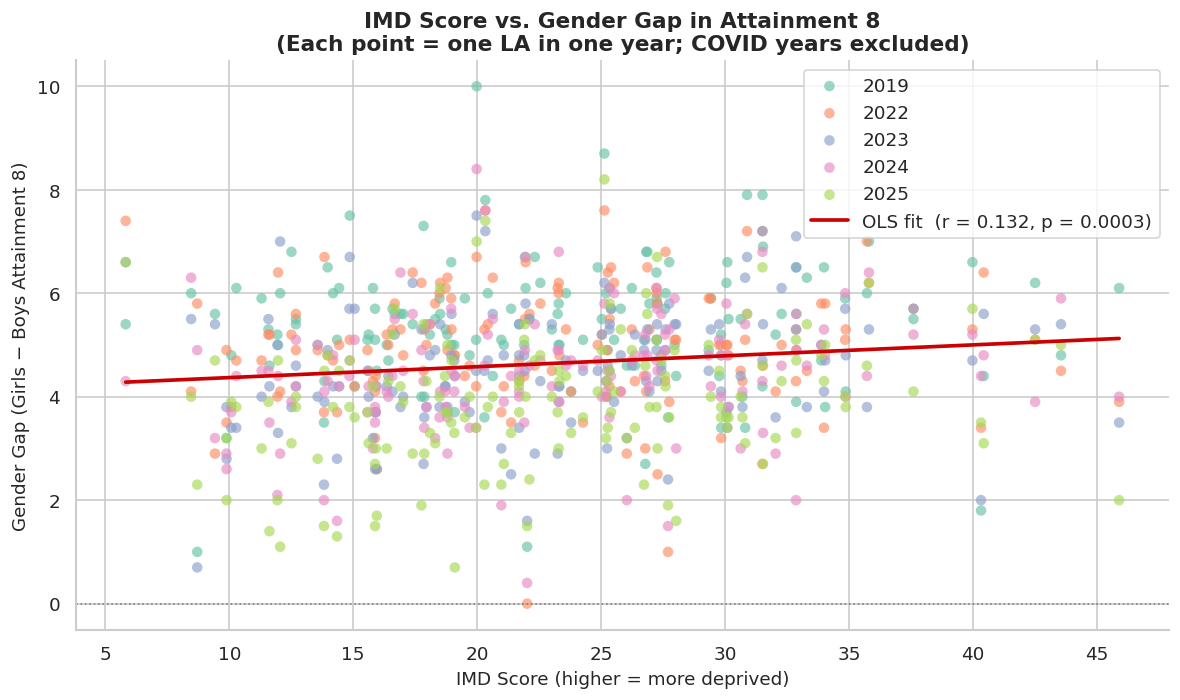


OLS regression: slope = 0.0211, r = 0.1321, p-value = 0.0003
Interpretation: For each 1-point increase in IMD score, the gender gap changes by +0.0211 Attainment 8 points.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each year with specific colors from a qualitative palette
years = sorted(gap_no_covid['end_year'].unique())
colors = sns.color_palette('Set2', len(years))

for yr, color in zip(years, colors):
    d = gap_no_covid[gap_no_covid['end_year'] == yr]
    ax.scatter(
        d['imd_score'],
        d['gap_attainment8_average'],
        color=color,
        alpha=0.65,
        s=40,
        edgecolors='none',
        label=str(yr)
    )

# OLS regression line
slope, intercept, r, p, se = stats.linregress(
    gap_no_covid['imd_score'],
    gap_no_covid['gap_attainment8_average']
)
x_line = np.linspace(gap_no_covid['imd_score'].min(),
                     gap_no_covid['imd_score'].max(), 200)
ax.plot(x_line, intercept + slope * x_line,
        color='#cc0000', linewidth=2.2, label=f'OLS fit  (r = {r:.3f}, p = {p:.4f})')

ax.axhline(0, color='grey', linewidth=1, linestyle=':')

ax.set_title('IMD Score vs. Gender Gap in Attainment 8\n'
             '(Each point = one LA in one year; COVID years excluded)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('IMD Score (higher = more deprived)', fontsize=11)
ax.set_ylabel('Gender Gap (Girls - Boys Attainment 8)', fontsize=11)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f'\nOLS regression: slope = {slope:.4f}, r = {r:.4f}, p-value = {p:.4f}')
print(f'Interpretation: For each 1-point increase in IMD score, the gender gap '
      f'changes by {slope:+.4f} Attainment 8 points.')


Although IMD is not a strong predictor of the gender gap (0.132 falls into the weak positive), it is statistically significant and unlikely to be due to chance (p value of 0.0003 is smaller than 0.05) and we could say that the IMD score explains around 1.7% of the variation in the gender gap (R² ≈ 0.017)

As deprivation increases, girls tend to outperform boys by a larger margin in Attainment 8.

The widening gap could occur because:

- Girls' attainment falls more slowly than boys' attainment as deprivation increases.
- Girls' attainment remains relatively stable while boys' attainment declines.
- Both groups decline with deprivation, but boys decline more sharply.

### 6.3 — Gender gap over time, by deprivation quintile (line chart)


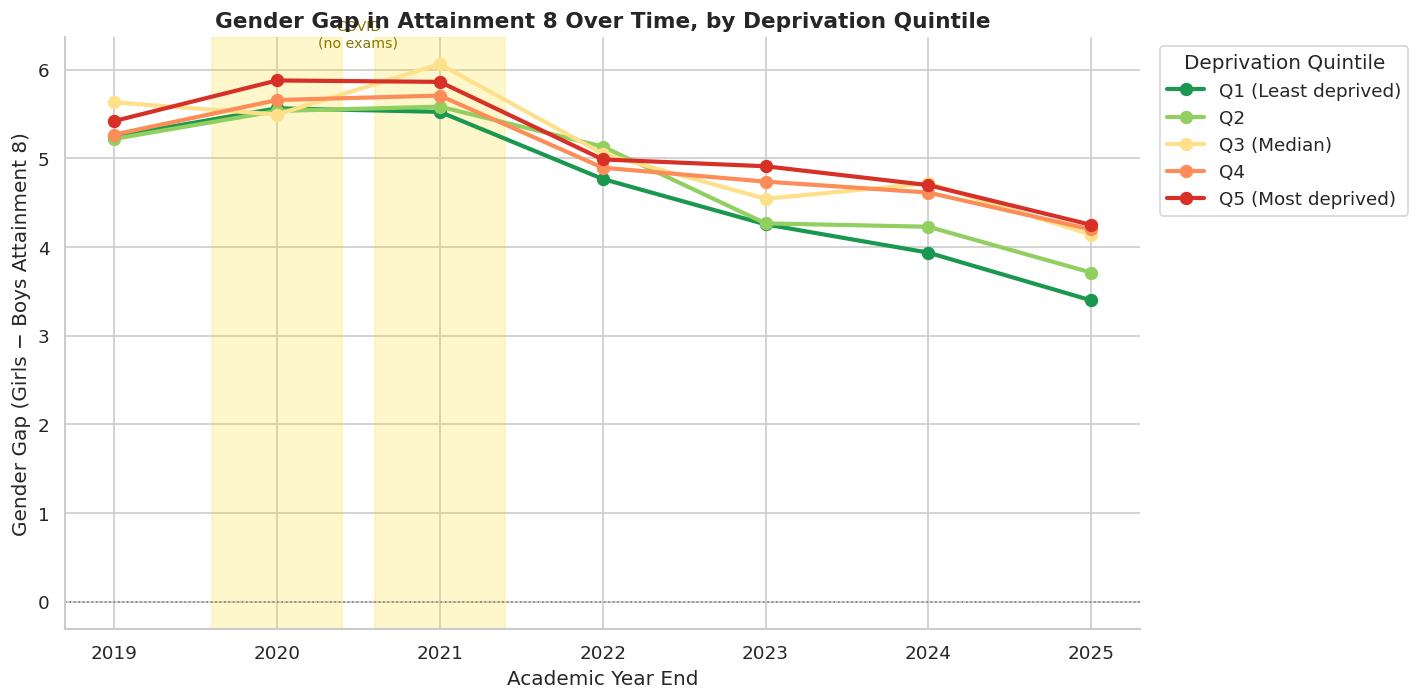

In [ ]:
gap_trend = (
    gap.groupby(["end_year", "dep_quintile"])["gap_attainment8_average"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

for i, quintile in enumerate(quintile_order):
    d = gap_trend[gap_trend["dep_quintile"] == quintile]
    ax.plot(d["end_year"], d["gap_attainment8_average"],
            color=QUINT_PALETTE[i], linewidth=2.5,
            marker="o", markersize=7, label=quintile)

# COVID shading
for yr in [2020, 2021]:
    ax.axvspan(yr - 0.4, yr + 0.4, color=COVID_COL, alpha=0.20)
ax.annotate("COVID\n(no exams)",
            xy=(2020.5, gap_trend["gap_attainment8_average"].max() + 0.2),
            fontsize=8.5, color="#8B7500", ha="center")

ax.axhline(0, color="grey", linewidth=1, linestyle=":")
ax.set_title("Gender Gap in Attainment 8 Over Time, by Deprivation Quintile",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Academic Year End")
ax.set_ylabel("Gender Gap (Girls - Boys Attainment 8)")
ax.set_xticks(sorted(gap["end_year"].unique()))
ax.legend(title="Deprivation Quintile", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 7. Subject-Level Gender Gaps by Deprivation Quintile

Different subjects may show different patterns. We examine the gender gap in:
- **English** (`attainment8eng_average`)
- **Maths** (`attainment8mat_average`)
- **EBacc overall** (`attainment8ebacc_average`)
- **Humanities** (`ebacchum_aps_average`)
- **Languages** (`ebacclan_aps_average`)
- **Science** (`ebaccsci_aps_average`)

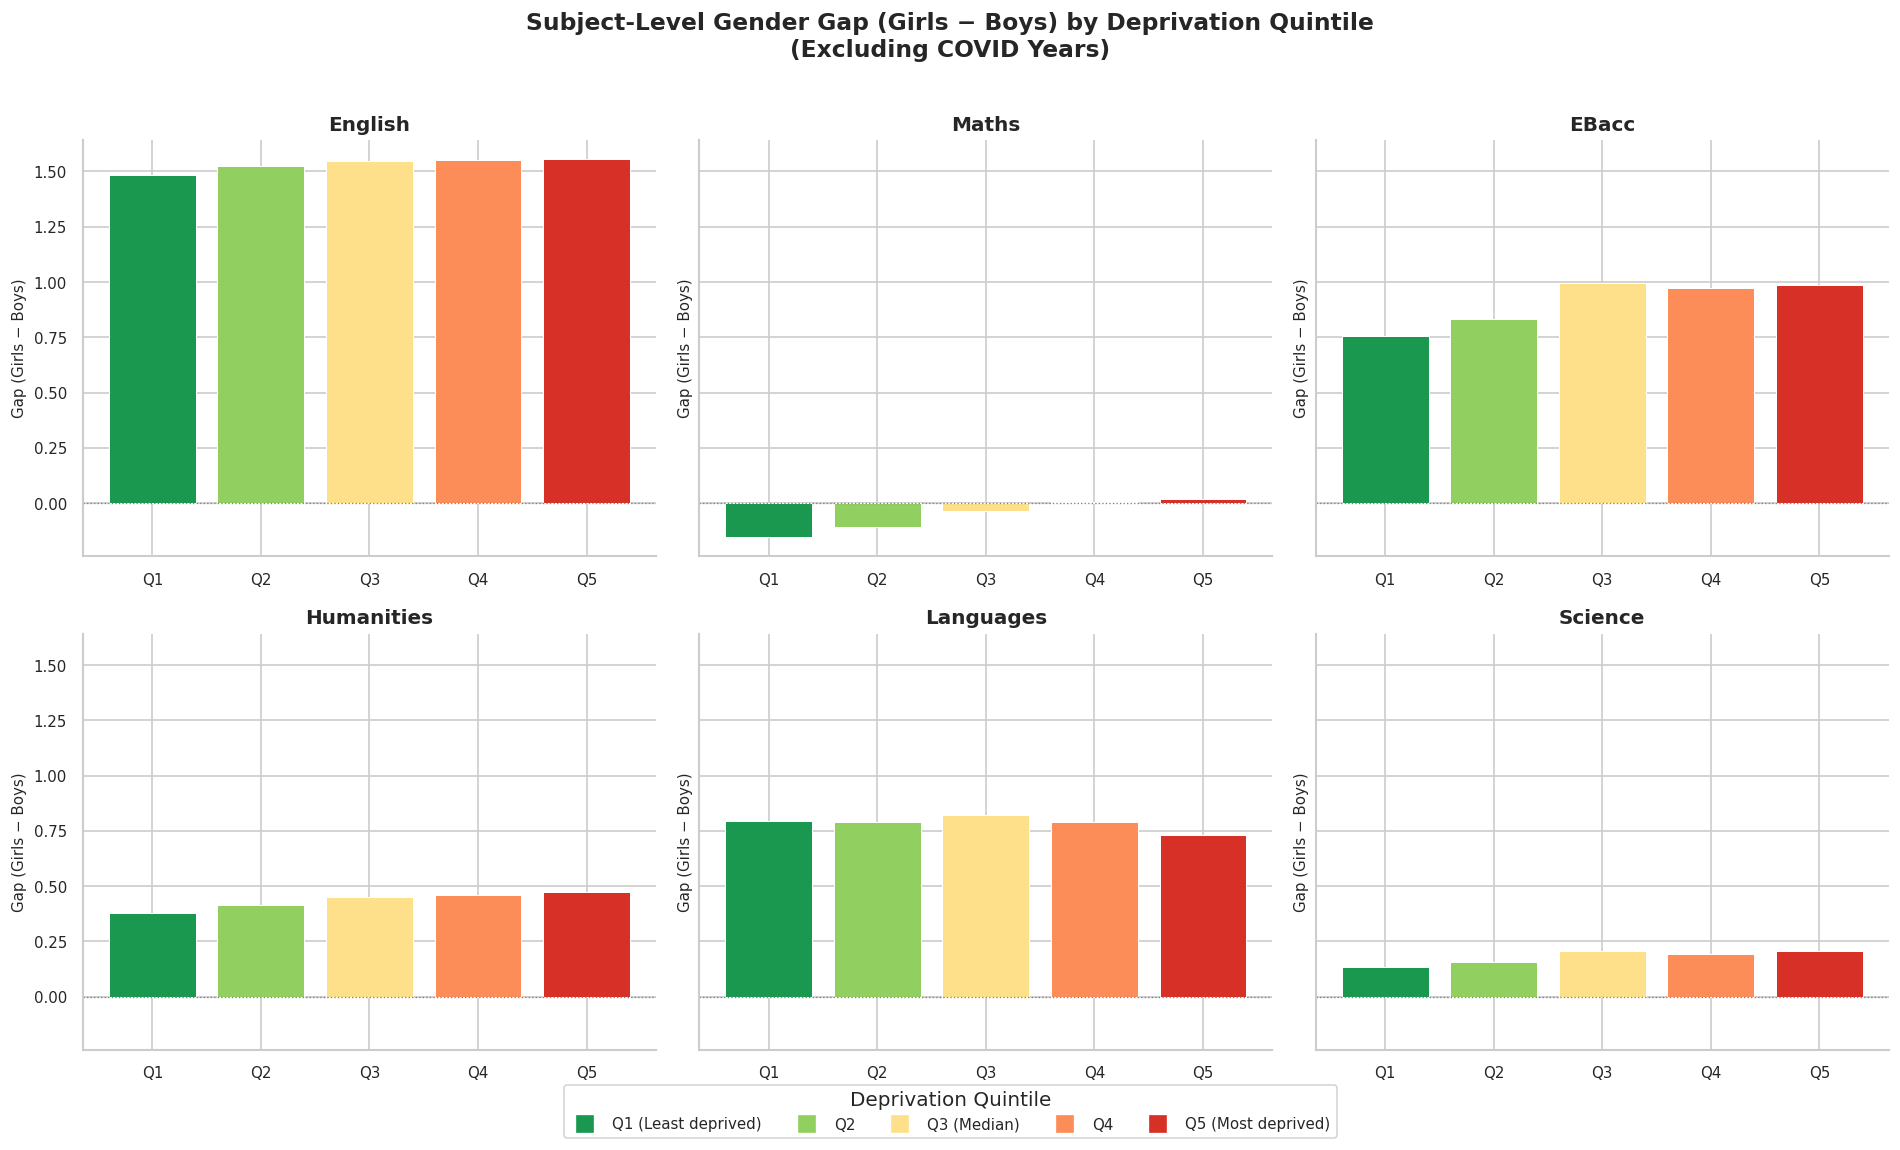

In [ ]:
subjects = {
    'English':     'gap_attainment8eng_average',
    'Maths':       'gap_attainment8mat_average',
    'EBacc':       'gap_attainment8ebacc_average',
    'Humanities':  'gap_ebacchum_aps_average',
    'Languages':   'gap_ebacclan_aps_average',
    'Science':     'gap_ebaccsci_aps_average',
}

# Build summary table
rows = []
for subj, col in subjects.items():
    for q in quintile_order:
        mean_val = gap_no_covid.loc[gap_no_covid['dep_quintile'] == q, col].mean()
        rows.append({'Subject': subj, 'Quintile': q, 'Mean Gap': mean_val})

subj_df = pd.DataFrame(rows)

# Faceted bar chart
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for ax, (subj, col) in zip(axes, subjects.items()):
    d = subj_df[subj_df['Subject'] == subj]
    bars = ax.bar(
        range(len(quintile_order)),
        d.set_index('Quintile').reindex(quintile_order)['Mean Gap'],
        color=QUINT_PALETTE,
        edgecolor='white', linewidth=0.6
    )
    ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
    ax.set_title(subj, fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(quintile_order)))
    ax.set_xticklabels(['Q1','Q2','Q3','Q4','Q5'], fontsize=9)
    ax.set_ylabel('Gap (Girls - Boys)', fontsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend for quintiles
legend_handles = [
    axes[0].plot([], [], 's', color=QUINT_PALETTE[i], markersize=10, label=q)[0]
    for i, q in enumerate(quintile_order)
]
fig.legend(handles=legend_handles, title='Deprivation Quintile',
           loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.04))

fig.suptitle('Subject-Level Gender Gap (Girls − Boys) by Deprivation Quintile\n'
             '(Excluding COVID Years)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 8. Statistical Analysis

### 8.1 — Pearson correlation: IMD score vs. gender gap

In [13]:
print("Pearson correlations between deprivation scores and gender gap in Attainment 8")
print("(Non-COVID years only)\n")
print(f"{'Deprivation Score':<45}  {'r':>7}  {'p-value':>10}  {'Interpretation':}")
print("-" * 85)

dep_vars = {
    "IMD Score (overall)": "imd_score",
    "Income Score": "income_score",
    "Employment Score": "employment_score",
    "Health Score": "health_score",
    "Crime Score": "crime_score",
    "Barriers to Housing Score": "barriers_score",
    "Living Environment Score": "living_env_score",
    "IDACI (Child Income Deprivation)": "idaci_score",
    "Children & Young People Sub-domain": "children_subdomain",
}

corr_rows = []
for label, col in dep_vars.items():
    r, p = stats.pearsonr(
        gap_no_covid[col],
        gap_no_covid["gap_attainment8_average"]
    )
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
    direction = "increase in deprivation → wider gap" if r > 0 else "increase in deprivation → narrower gap"
    print(f"{label:<45}  {r:>+7.4f}  {p:>10.4f}  {sig}  {direction}")
    corr_rows.append({"Deprivation": label, "r": round(r,4), "p": round(p,4)})

print("\nSignificance: *** p<0.001 | ** p<0.01 | * p<0.05 | n.s. not significant")

Pearson correlations between deprivation scores and gender gap in Attainment 8
(Non-COVID years only)

Deprivation Score                                    r     p-value  Interpretation
-------------------------------------------------------------------------------------
IMD Score (overall)                            +0.1321      0.0003  ***  increase in deprivation → wider gap
Income Score                                   +0.1394      0.0001  ***  increase in deprivation → wider gap
Employment Score                               +0.1052      0.0040  **  increase in deprivation → wider gap
Health Score                                   +0.1071      0.0034  **  increase in deprivation → wider gap
Crime Score                                    +0.1043      0.0043  **  increase in deprivation → wider gap
Barriers to Housing Score                      +0.0012      0.9732  n.s.  increase in deprivation → wider gap
Living Environment Score                       +0.0820      0.0250  *  incre

### 8.2 — One-way ANOVA and Follow-up T-test
We first run an ANOVA to see if the gap is significantly different across all quintiles, followed by a targeted t-test comparing the extremes (Q1 vs Q5).

In [14]:
groups = [
    gap_no_covid.loc[gap_no_covid["dep_quintile"] == q, "gap_attainment8_average"].dropna().values
    for q in quintile_order
]

f_stat, p_val = stats.f_oneway(*groups)

print("One-way ANOVA: gender gap in Attainment 8 across deprivation quintiles")
print(f"F-statistic = {f_stat:.4f}")
print(f"p-value     = {p_val:.6f}")

if p_val < 0.05:
    print("\n→ Result is statistically significant (p < 0.05): the mean gender gap differs significantly across at least two deprivation quintiles.")
else:
    print("\n→ Result is not statistically significant (p ≥ 0.05).")

print("\n" + "-"*50 + "\n")

q1 = groups[0] # Q1 (Least deprived)
q5 = groups[4] # Q5 (Most deprived)
q3 = groups[2] # Q3 (Median)

t_stat_15, p_val_15 = stats.ttest_ind(q1, q5)
t_stat_35, p_val_35 = stats.ttest_ind(q3, q5)

print("Post-hoc T-test: gender gap in Attainment 8 between Q1 (Least deprived) and Q5 (Most deprived)")
print(f"t-statistic = {t_stat_15:.4f}")
print(f"p-value     = {p_val_15:.6f}")
if p_val_15 < 0.05:
    print("\n→ Result is statistically significant (p < 0.05).")
else:
    print("\n→ Result is not statistically significant (p ≥ 0.05).")
print("\n" + "-"*50 + "\n")

print("Post-hoc T-test: gender gap in Attainment 8 between Q3 (Median) and Q5 (Most deprived)")
print(f"t-statistic = {t_stat_35:.4f}")
print(f"p-value     = {p_val_35:.6f}")
if p_val_35 < 0.05:
    print("\n→ Result is statistically significant (p < 0.05).")
else:
    print("\n→ Result is not statistically significant (p ≥ 0.05).")


One-way ANOVA: gender gap in Attainment 8 across deprivation quintiles
F-statistic = 5.1196
p-value     = 0.000450

→ Result is statistically significant (p < 0.05): the mean gender gap differs significantly across at least two deprivation quintiles.

--------------------------------------------------

Post-hoc T-test: gender gap in Attainment 8 between Q1 (Least deprived) and Q5 (Most deprived)
t-statistic = -3.7633
p-value     = 0.000201

→ Result is statistically significant (p < 0.05).

--------------------------------------------------

Post-hoc T-test: gender gap in Attainment 8 between Q3 (Median) and Q5 (Most deprived)
t-statistic = -0.2747
p-value     = 0.783715

→ Result is not statistically significant (p ≥ 0.05).


## 9. Summary Statistics Table

In [15]:
summary = (
    gap_no_covid.groupby("dep_quintile")
    .agg(
        n_observations=("gap_attainment8_average", "count"),
        mean_imd_score=("imd_score", "mean"),
        girls_mean_att8=("girls_attainment8_average", "mean"),
        boys_mean_att8=("boys_attainment8_average", "mean"),
        mean_gap=("gap_attainment8_average", "mean"),
        std_gap=("gap_attainment8_average", "std"),
        min_gap=("gap_attainment8_average", "min"),
        max_gap=("gap_attainment8_average", "max"),
    )
    .reindex(quintile_order)
    .round(2)
)

summary.index.name = "Deprivation Quintile"
print("Summary: Gender Gap in Attainment 8 by Deprivation Quintile (Non-COVID Years)")
print("=" * 100)
print(summary.to_string())

Summary: Gender Gap in Attainment 8 by Deprivation Quintile (Non-COVID Years)
                      n_observations  mean_imd_score  girls_mean_att8  boys_mean_att8  mean_gap  std_gap  min_gap  max_gap
Deprivation Quintile                                                                                                      
Q1 (Least deprived)              152           12.46            52.09           47.78      4.30     1.33      0.7      7.5
Q2                               142           17.92            49.91           45.41      4.50     1.07      0.7      7.3
Q3 (Median)                      148           22.45            50.09           45.28      4.81     1.53      0.0     10.0
Q4                               150           27.08            48.29           43.55      4.74     1.12      1.0      6.8
Q5 (Most deprived)               155           34.44            45.72           40.87      4.85     1.22      1.8      7.9


## 10. Conclusions

### Key Findings

1. **Girls consistently outperform boys** in Attainment 8 across all deprivation quintiles and all academic years (2019–2025), confirming the well-known national gender gap.

2. **The gender gap changes with deprivation level, showing clear directionality.** While girls perform better than boys across all deprivation levels, the gender gap is wider in more deprived areas (where girls perform relatively better compared to boys, with a gap of 4.88 points in Q5), whereas boys perform relatively better in less deprived areas (narrowing the gap to 4.29 points in Q1).

3. **Subject-level variation matters.** The analysis shows that the gap is not uniform across subjects:
   - **English and Humanities** show the largest pro-girls gaps across all quintiles.
   - **Maths** tends to show a smaller or sometimes reversed gap depending on deprivation level.
   - **Languages** shows a consistently strong pro-girls gap, regardless of deprivation.

4. **Temporal trends show widening inequality between quintiles.** Overall, the gender gap has been steadily narrowing across all deprivation quintiles since the return to formal examinations in 2022. However, this narrowing has been highly uneven: the gap has shrunk much faster in the least deprived areas (Q1) than in the most deprived areas (Q5). As a result, while the national gender gap is smaller today than it was in 2019, the inequality *between* rich and poor areas has actually widened over time.

5. **COVID-19 distorted the pattern.** The 2020 and 2021 academic years (teacher-assessed grades) temporarily inflated the gap across all quintiles and should be interpreted with caution.

8. **Statistical significance:** The one-way ANOVA confirms that the gender gap differs significantly across deprivation quintiles overall. A targeted follow-up t-test proves that the difference in the gap between the least deprived (Q1) and most deprived (Q5) areas is statistically significant. However, a comparison between the median (Q3) and most deprived (Q5) areas was not statistically significant, suggesting that the most severe widening of the gap is primarily visible when comparing the absolute extremes of wealth and deprivation.


6. **IMD and Gender Gap Relationship:** Although IMD is not a strong predictor of the gender gap (0.132 falls into the weak positive), it is statistically significant and unlikely to be due to chance (p value of 0.0003 is smaller than 0.05) and we could say that the IMD score explains around 1.7% of the variation in the gender gap (R² ≈ 0.017)
   
   As deprivation increases, girls tend to outperform boys by a larger margin in Attainment 8.
   
   The widening gap could occur because:
   
   - Girls' attainment falls more slowly than boys' attainment as deprivation increases.
   - Girls' attainment remains relatively stable while boys' attainment declines.
   - Both groups decline with deprivation, but boys decline more sharply.

### Policy Implications

If the gender gap is wider (or narrower) in more deprived areas, this has implications for targeted interventions:
- Programmes supporting boys' literacy and engagement may be especially important in high-deprivation LAs.
- Subject-specific gaps in Languages and Humanities suggest curriculum-level factors that interact with both gender and deprivation.
